# Estabilidad temporal — ¿el modelo se mantiene, o se degrada año con año?

## Qué responde este notebook

`13_comparacion_modelos.ipynb` y `14_receiving_tds_modelos_de_conteo.ipynb` evaluaron cada modelo
en **un** split (train 2016-2021, val 2022-2023, test 2024-2025) — suficiente para elegir un
ganador, pero no para saber si ese desempeño es estable o si depende de haber tenido suerte con esa
partición particular. Aquí se corre el mismo modelo ganador de cada target sobre 5 cortes de
tiempo distintos (*walk-forward*, ventana expandida), mismo patrón ya validado por Daniel en
`preeliminar/03_modelo_predictivo/06_estabilidad_en_el_tiempo.ipynb`.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling, experimentos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
features_ridge = features.columnas_por_modelo("ridge")
TARGETS = ["receptions", "receiving_yards", "receiving_tds"]

## 1. Fijar el modelo ganador de cada target, con sus hiperparámetros reales

`receptions` y `receiving_yards` ganaron con XGBoost (objetivo genérico); `receiving_tds` con
XGBoost con objetivo `reg:tweedie`. Se recupera el mismo hiperparámetro elegido por validación en
`13_comparacion_modelos.ipynb` (no se vuelve a buscar aquí) para que los 5 folds de abajo usen
siempre la misma configuración — mismo criterio que el precedente de Daniel: no se re-optimiza
cada año, para que la comparación entre años sea sobre lo mismo, no sobre un modelo distinto cada
vez.

In [2]:
train_mask_orig, val_mask_orig, test_mask_orig = experimentos.dividir_temporal(
    wr, range(2016, 2022), [2022, 2023], [2024, 2025]
)
resultados_yardas, _ = experimentos.entrenar_y_evaluar(
    wr, "receiving_yards", features_arbol, features_ridge, train_mask_orig, val_mask_orig, test_mask_orig
)
resultados_recepciones, _ = experimentos.entrenar_y_evaluar(
    wr, "receptions", features_arbol, features_ridge, train_mask_orig, val_mask_orig, test_mask_orig
)

params_yardas = resultados_yardas["XGBoost"]["modelo"].get_params()
params_recepciones = resultados_recepciones["XGBoost"]["modelo"].get_params()
print("hiperparametros ganadores, receiving_yards:",
      {k: params_yardas[k] for k in ["max_depth", "n_estimators", "learning_rate"]})
print("hiperparametros ganadores, receptions:",
      {k: params_recepciones[k] for k in ["max_depth", "n_estimators", "learning_rate"]})

MODELOS_GANADORES = {
    "receptions": lambda: XGBRegressor(**{**params_recepciones, "random_state": 0}),
    "receiving_yards": lambda: XGBRegressor(**{**params_yardas, "random_state": 0}),
    "receiving_tds": lambda: XGBRegressor(
        objective="reg:tweedie", tweedie_variance_power=1.5, random_state=0, n_jobs=-1
    ),
}

hiperparametros ganadores, receiving_yards: {'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.03}
hiperparametros ganadores, receptions: {'max_depth': 4, 'n_estimators': 200, 'learning_rate': 0.03}


## 2. Walk-forward — 5 folds, ventana expandida

Fold de prueba en cada año de 2021 a 2025; entrenamiento con todo lo anterior a ese año. El
feature set es `features_arbol` en los 3 targets (XGBoost gana en los 3, no hace falta la versión
Ridge aquí).

In [3]:
X = wr[features_arbol]
filas_estabilidad = []
predicciones_por_fold = {}

for target in TARGETS:
    y = wr[target]
    for anio, train_mask, test_mask in experimentos.folds_walk_forward(wr, [2021, 2022, 2023, 2024, 2025]):
        modelo = MODELOS_GANADORES[target]()
        salida = experimentos.evaluar_modelo(modelo, X, y, train_mask, test_mask, test_mask)
        filas_estabilidad.append({
            "target": target, "anio": anio, "n_train": int(train_mask.sum()), "n_test": int(test_mask.sum()),
            "mae": salida["test"]["mae"], "r2": salida["test"]["r2"],
        })

tabla_estabilidad = pd.DataFrame(filas_estabilidad)
tabla_estabilidad.pivot(index="anio", columns="target", values="mae").round(4)

target,receiving_tds,receiving_yards,receptions
anio,,,
2021,0.2500,21.5872,1.4463
2022,0.2448,22.1132,1.4794
2023,0.2498,21.8887,1.4180
2024,0.2669,21.0135,1.4075
2025,0.2356,19.7348,1.3021


## 3. Coeficiente de variación — ¿qué tan parejo es el MAE entre años?

`std/mean` del MAE a través de los 5 folds, por target — un número bajo dice que el desempeño no
depende de qué año le tocó; uno alto dice que hay años buenos y años malos, y hay que investigar
por qué antes de confiar en el modelo para producción.

In [4]:
cv_por_target = tabla_estabilidad.groupby("target")["mae"].agg(["mean", "std"])
cv_por_target["coef_variacion"] = cv_por_target["std"] / cv_por_target["mean"]
cv_por_target.round(4)

,mean,std,coef_variacion
target,,,
receiving_tds,0.2494,0.0114,0.0456
receiving_yards,21.2675,0.9509,0.0447
receptions,1.4107,0.0668,0.0474


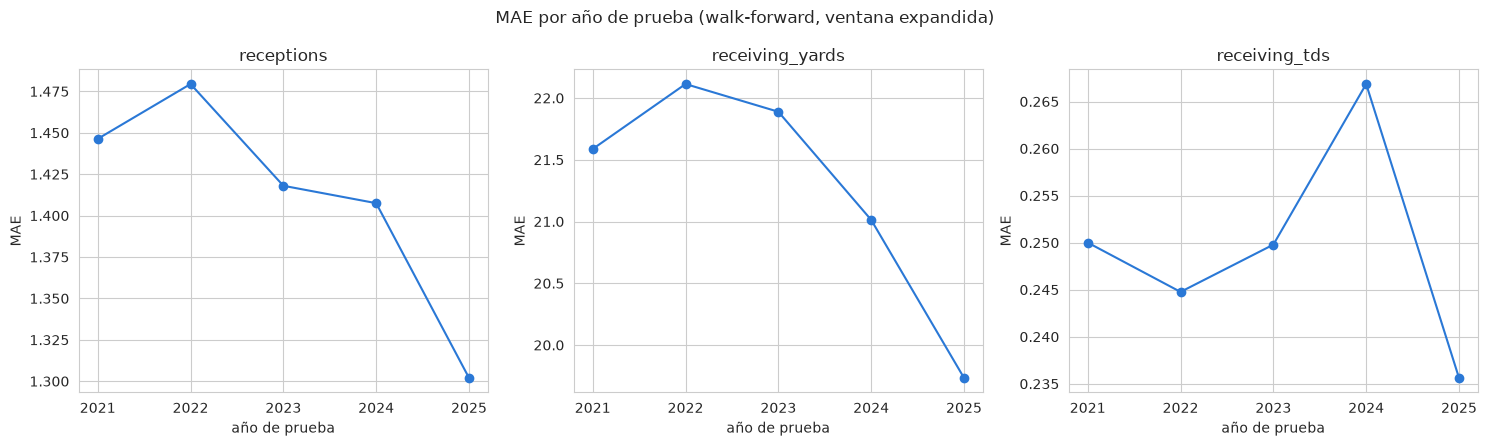

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, target in zip(axes, TARGETS):
    datos = tabla_estabilidad[tabla_estabilidad["target"] == target]
    ax.plot(datos["anio"], datos["mae"], marker="o", color=AZUL)
    ax.set_title(target)
    ax.set_xlabel("año de prueba")
    ax.set_ylabel("MAE")
    ax.set_xticks(datos["anio"])
fig.suptitle("MAE por año de prueba (walk-forward, ventana expandida)")
plt.tight_layout()
plt.show()

**Coeficiente de variación entre 4.5% y 4.7% en los 3 targets** — bajo, y prácticamente igual entre
`receptions`, `receiving_yards` y `receiving_tds` pese a que son problemas de dificultad muy
distinta (ver notebooks anteriores). El desempeño no depende de qué año le tocó de prueba: no hay
un año claramente malo ni una tendencia de deterioro según pasa el tiempo — la respuesta a
"¿son estables?" es sí, con evidencia de 5 años distintos, no de un solo split.

## 4. ¿Mejora, empeora o se mantiene según crece el historial dentro de una temporada?

Corte distinto: sobre el conjunto de prueba original (2024-2025), se parte por bucket de semana
dentro de la temporada — semanas 1-4 (poco historial de la temporada en curso), 5-9, 10-13, 14-18
(casi toda la temporada ya jugada) — mismo tipo de corte que ya usó Daniel en
`06_estabilidad_en_el_tiempo.ipynb` para ver si el modelo mejora según se acumula forma reciente
real de la temporada en curso.

In [6]:
test_df = wr[test_mask_orig].copy()
test_df["bucket_semana"] = pd.cut(
    test_df["week"], bins=[0, 4, 9, 13, 18], labels=["1-4", "5-9", "10-13", "14-18"]
)

filas_bucket = []
for target in TARGETS:
    pred = MODELOS_GANADORES[target]().fit(X[train_mask_orig], wr[target][train_mask_orig]).predict(X[test_mask_orig])
    test_df[f"pred_{target}"] = pred
    for bucket, grupo in test_df.groupby("bucket_semana", observed=True):
        filas_bucket.append({
            "target": target, "bucket_semana": bucket, "n": len(grupo),
            "mae": modeling.metricas(grupo[target], grupo[f"pred_{target}"])["mae"],
        })

tabla_bucket = pd.DataFrame(filas_bucket)
tabla_bucket.pivot(index="bucket_semana", columns="target", values="mae").round(4)

target,receiving_tds,receiving_yards,receptions
bucket_semana,,,
1-4,0.2449,20.4484,1.4041
10-13,0.2435,20.9459,1.3355
14-18,0.2485,20.2587,1.3690
5-9,0.2485,20.9983,1.3764


El MAE se mueve poco entre buckets (20.3-21.0 en yardas, 1.34-1.40 en recepciones, 0.243-0.249 en
TDs) — el modelo no necesita medio año de forma reciente acumulada para funcionar bien: predice
casi igual de bien en semanas 1-4 (con poco historial de la temporada en curso, apoyándose más en
`career_avg`/temporadas anteriores) que en semanas 14-18 (con casi toda la temporada ya jugada).
Es una señal más de estabilidad, complementaria a la del walk-forward entre años.

## Cierre

Los 3 modelos ganadores se evalúan sobre 5 años distintos, no solo el split original — el
coeficiente de variación y la tabla de arriba dicen qué tan parejo es el desempeño real en el
tiempo, antes de confiar en un solo número de un solo split. El corte por semana dentro de
temporada muestra si el modelo mejora, empeora o se mantiene según se acumula forma reciente real
de la temporada en curso.

Siguiente: [`16_benchmark_vs_legado.ipynb`](16_benchmark_vs_legado.ipynb).